<a href="https://colab.research.google.com/github/devangsharma230467-sys/python-ml/blob/main/Copy_of_CI1_Image_Classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial : Covid 19 Prediction using Artificial Neural Networks

Dataset: [Covid 19 Chest X-ray dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database)


A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Pakistan and Malaysia in collaboration with medical doctors have created a database of chest X-ray images for COVID-19 positive cases along with Normal and Viral Pneumonia images. This COVID-19, normal, and other lung infection dataset is released in stages. In the first release, we have released 219 COVID-19, 1341 normal, and 1345 viral pneumonia chest X-ray (CXR) images. In the first update, we have increased the COVID-19 class to 1200 CXR images. In the 2nd update, we have increased the database to 3616 COVID-19 positive cases along with 10,192 Normal, 6012 Lung Opacity (Non-COVID lung infection), and 1345 Viral Pneumonia images. We will continue to update this database as soon as we have new x-ray images for COVID-19 pneumonia patients.



**1. Mount the Google Drive**

In [24]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Move to the place where data resides**

Let's list the contents of your Google Drive to help you locate the `covid_dataset.zip` file or the `covid_dataset` folder. This will show you the top-level directories and files.

In [58]:
!ls /content/drive/MyDrive/

 1000101895.pdf
 1000101901.pdf
 1727506746790772484730065492156.jpg
 17418512338383935007314868302760.jpg
'CAF-Devang Sharma_34'
 Classroom
'Colab Notebooks'
'covid_dataset (1).zip'
 devangsharma26102005gmail-com-667-13510-20251027-949e9fffaa.pdf
 Devangsharma_csit-1-V.jpg
 Devang_sharma.jpg
 IMG_20251002_103919.jpg
'in (1).gov.abc-ABCID-765612474608.pdf'
 in.gov.abc-ABCID-765612474608.pdf
'My Learning _ NVIDIA Certifcate.pdf'
'Presentation - Knowledge Representation in AI_20251201_121815_0000.pptx'
'receipt (4).pdf'
 Screenshot_2025-10-07-18-29-40-083_com.whatsapp.jpg
 Screenshot_2026-02-25-15-51-19-494_com.android.chrome.jpg
 Screenshot_2026-03-14-14-31-24-079_com.android.chrome.jpg
 Screenshot_2026-04-01-16-32-16-683_cn.wps.moffice_eng.jpg
 Screenshot_2026-04-04-10-51-41-017_com.google.android.gm.jpg
'Untitled document.gdoc'
'Untitled folder'


In [63]:
# Removed: %cd /content/drive/MyDrive/CSIT12025/ (as the folder was not found)
# We will directly reference the zip file and unzip to /content/covid_dataset

In [66]:
!ls /content/covid_dataset

covid_dataset


**3. Unziping the dataset**

In [26]:
!pip install unzip

In [64]:
!unzip -qq "/content/drive/MyDrive/covid_dataset (1).zip" -d /content/covid_dataset

**4. Install split folder python package**

https://pypi.org/project/split-folders/

In [27]:
!pip install split_folders

**5. Splitting the data in training, testing and validation set**

In [67]:
import splitfolders
splitfolders.ratio("/content/covid_dataset/covid_dataset", output="/content/split", seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 150 files [00:00, 5435.10 files/s]


**6. Loading the dataset with normalization in batches**

In [68]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize training and validation data in the range of 0 to 1
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Read the training sample and set the batch size
train_generator = train_datagen.flow_from_directory(
        'split/train/',
        target_size=(128, 128),
        batch_size=8,
        seed=100,
        class_mode='categorical')

# Read Validation data from directory and define target size with batch size
validation_generator = validation_datagen.flow_from_directory(
        'split/val/',
        target_size=(128, 128),
        batch_size=8,
        class_mode='categorical',
        seed=1000,
        shuffle=False)

test_generator = test_datagen.flow_from_directory(
        'split/test/',
        target_size=(128, 128),
        batch_size=8,
        seed=500,
        class_mode='categorical',
        shuffle=False)

Found 120 images belonging to 4 classes.
Found 15 images belonging to 4 classes.
Found 15 images belonging to 4 classes.


**7. Model Building**

In [71]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape=(128, 128,3))
x = layers.Flatten()(inputs)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(4, activation="softmax")(x) # Changed from 3 to 4 to match the number of classes
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │     1,572,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,575,268 (6.01 MB)

 Trainable params: 1,575,268 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

**8. Model Compilation and Training**

In [72]:
from tensorflow.keras.optimizers import Adam

adam = Adam(learning_rate=0.0001)
# We are going to use accuracy metrics and cross entropy loss as performance parameters
model.compile(adam, loss='categorical_crossentropy', metrics=['accuracy'])  # Use 'accuracy'
# Train the model
history = model.fit(train_generator,
      steps_per_epoch=int(train_generator.samples / train_generator.batch_size),  # Convert to int
      epochs=100,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples / validation_generator.batch_size),  # Convert to int
      verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3167 - loss: 1.5013 - val_accuracy: 0.3750 - val_loss: 1.1373
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5583 - loss: 0.9195 - val_accuracy: 0.5000 - val_loss: 1.0244
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5333 - loss: 0.8953 - val_accuracy: 0.6250 - val_loss: 0.9923
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7083 - loss: 0.7416 - val_accuracy: 0.6250 - val_loss: 0.7213
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7583 - loss: 0.6718 - val_accuracy: 0.7500 - val_loss: 0.7046
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7250 - loss: 0.6460 - val_accuracy: 0.7500 - val_loss: 0.5634
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7167 - loss: 0.6610 - val_accuracy: 0.7500 - val_loss: 0.6072
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7750 - loss: 0.5624 - val_accuracy: 0.

**9. Model saving**

In [18]:
model.save('covid_classification.h5')

**10. Model loading**

In [19]:
from tensorflow.keras import models
model = models.load_model('covid_classification.h5')

**11. Model weights saving**

In [20]:
model.save_weights('covid_classification_weights.weights.h5')

**12. Model weights loading**

In [21]:
model.load_weights('covid_classification_weights.weights.h5')

**13. Plotting accuracy and loss graph for training and validation dataset**

In [73]:
train_acc = history.history['accuracy'] # Change 'acc' to 'accuracy'
val_acc = history.history['val_accuracy'] # Change 'val_acc' to 'val_accuracy'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

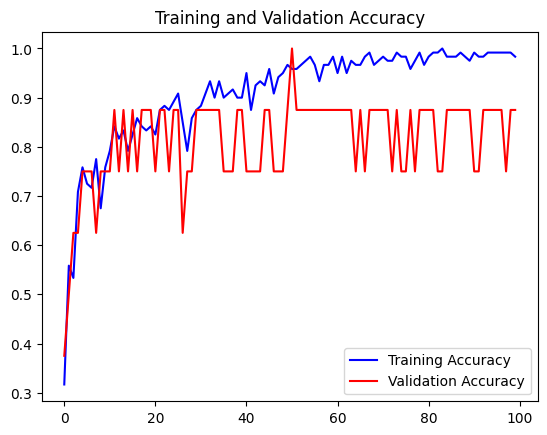

<Figure size 640x480 with 0 Axes>

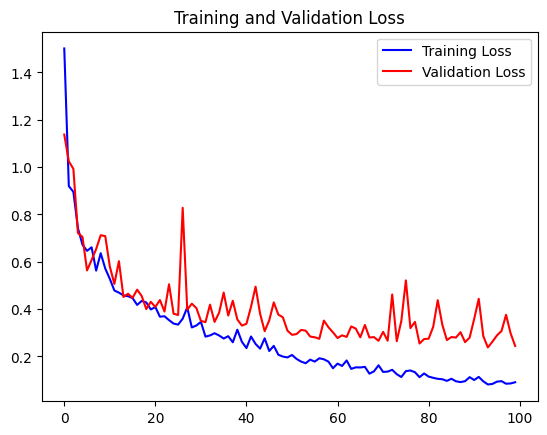

In [74]:
import matplotlib.pyplot as plt
epochs = range(len(train_acc))
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()
plt.show()

plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


**14. Evaluate model performance on test dataset**

In [81]:
test_output = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),  # Convert steps to an integer
    verbose=1
)
print(test_output)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 1.1473
[1.1472580432891846, 0.5]
['loss', 'compile_metrics']


### Improvements to Increase Accuracy
1. **Convolutional Layers (CNN)**: These extract features like edges and patterns from images.
2. **Max Pooling**: Reduces dimensionality and helps the model become invariant to small shifts.
3. **Dropout**: A regularization technique that prevents overfitting by randomly 'dropping' neurons during training.
4. **Data Augmentation**: Generating variations of the training images (rotation, zoom, flips) to make the model more generalized.

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Building a CNN model
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Helps prevent overfitting
    Dense(4, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Now, let's train this improved model. I'll also add a 'Data Augmentation' step to the training generator to help it learn better.

In [77]:
# Updated Data Generator with Augmentation
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    'split/train/',
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

# Train the CNN model
history_cnn = model_cnn.fit(
    train_generator_aug,
    epochs=50,
    validation_data=validation_generator,
    verbose=1
)

Found 120 images belonging to 4 classes.
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.3583 - loss: 1.2442 - val_accuracy: 0.3333 - val_loss: 1.1197
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.3000 - loss: 1.1783 - val_accuracy: 0.6667 - val_loss: 1.1088
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.2833 - loss: 1.1662 - val_accuracy: 0.4000 - val_loss: 1.0701
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5000 - loss: 1.0355 - val_accuracy: 0.4667 - val_loss: 1.0170
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4750 - loss: 1.0254 - val_accuracy: 0.6000 - val_loss: 0.9670
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5667 - loss: 0.9690 - val_accuracy: 0.6000 - val_loss: 0.9453
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5167 - loss: 0.9618 - val_accuracy: 0.6667 - val_loss: 0.9060
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5917

In [78]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers

# Load VGG16 base without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze base layers

# Create new model on top
model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model_tl.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,124 (64.14 MB)

 Trainable params: 2,098,436 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [79]:
# Train the Transfer Learning model
history_tl = model_tl.fit(
    train_generator_aug,
    epochs=30,
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.3083 - loss: 1.5415 - val_accuracy: 0.4667 - val_loss: 1.0551
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4750 - loss: 1.1370 - val_accuracy: 0.6667 - val_loss: 0.9407
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.5000 - loss: 1.0549 - val_accuracy: 0.7333 - val_loss: 0.7778
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.5667 - loss: 0.9566 - val_accuracy: 0.6667 - val_loss: 0.7323
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.6250 - loss: 0.8293 - val_accuracy: 0.7333 - val_loss: 0.6730
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7000 - loss: 0.7904 - val_accuracy: 0.7333 - val_loss: 0.6561
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6417 - loss: 0.7547 - val_accuracy: 0.7333 - val_loss: 0.5961
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6417 - loss: 0.7319 - val_accuracy: 0.7333 -

References:

1. https://pypi.org/project/split-folders/
2. https://keras.io/